In [1]:
 # importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading dataset

df = pd.read_csv(
    'wine_data.csv',
    header=None,
    usecols=[0, 1, 2]
)

df.columns = [
    'Class label',
    'Alcohol',
    'Malic acid'
]

In [3]:
# displaying dataset

df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


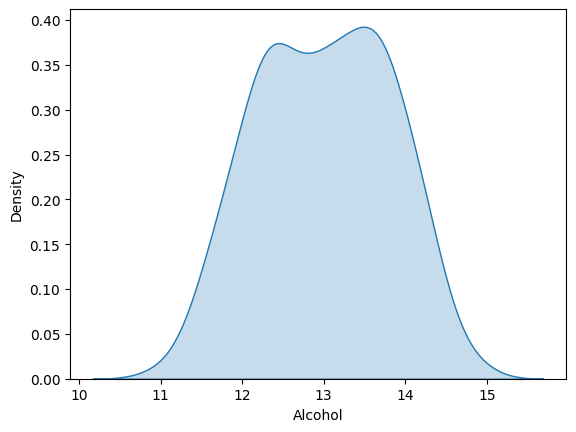

In [4]:
# alcohol distribution

sns.kdeplot(
    data=df,
    x='Alcohol',
    fill=True
)

plt.show()

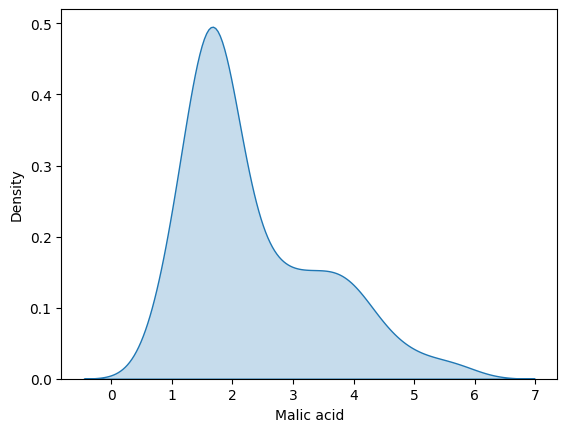

In [5]:
# malic acid distribution

sns.kdeplot(
    data=df,
    x='Malic acid',
    fill=True
)

plt.show()

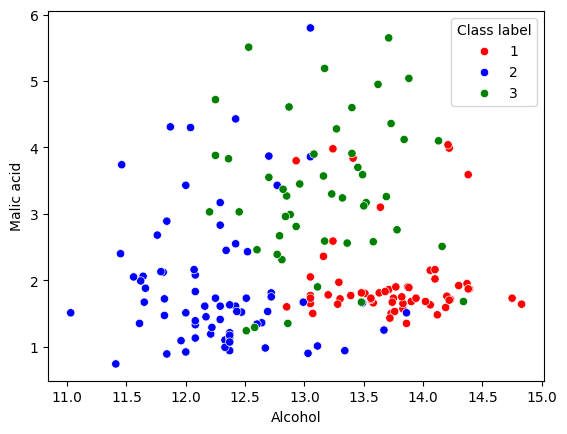

In [6]:
# scatter plot before scaling

color_dict = {
    1: 'red',
    2: 'blue',
    3: 'green'
}

sns.scatterplot(
    data=df,
    x='Alcohol',
    y='Malic acid',
    hue='Class label',
    palette=color_dict
)

plt.show()

In [7]:
# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Class label', axis=1),
    df['Class label'],
    test_size=0.3,
    random_state=0
)

In [8]:
# min max scaling

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# converting scaled arrays back to dataframe

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [10]:
# statistics before scaling

np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [11]:
# statistics after scaling

np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


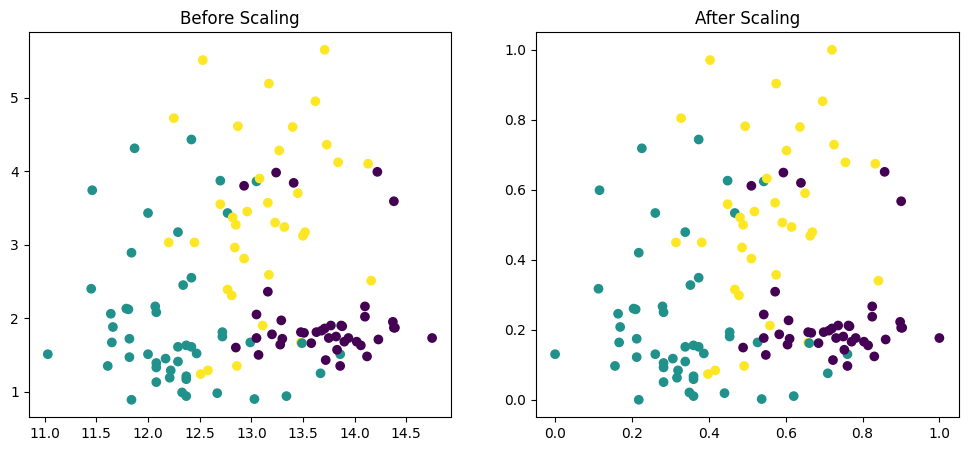

In [12]:
# scatter plot before and after scaling

fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(12, 5)
)

ax1.scatter(
    X_train['Alcohol'],
    X_train['Malic acid'],
    c=y_train
)

ax1.set_title('Before Scaling')

ax2.scatter(
    X_train_scaled['Alcohol'],
    X_train_scaled['Malic acid'],
    c=y_train
)

ax2.set_title('After Scaling')

plt.show()

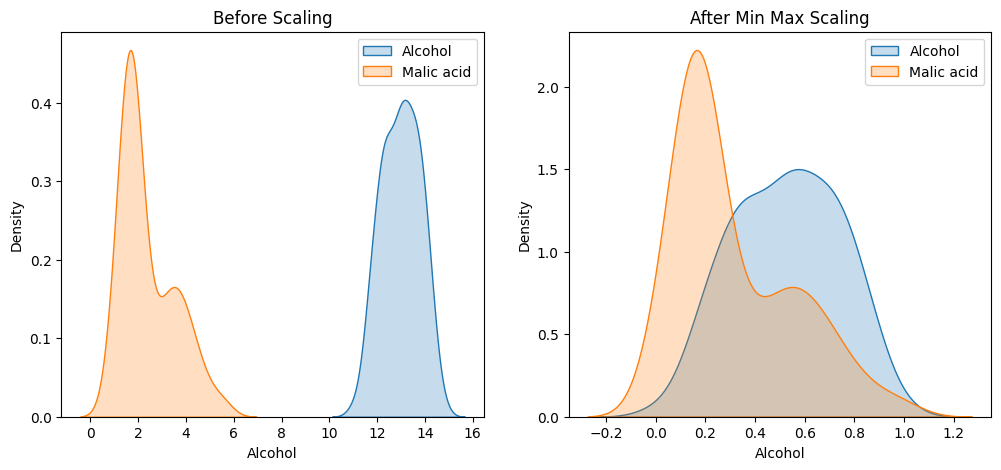

In [13]:
# distribution comparison

fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(12, 5)
)

ax1.set_title('Before Scaling')

sns.kdeplot(
    data=X_train,
    x='Alcohol',
    ax=ax1,
    label='Alcohol',
    fill=True
)

sns.kdeplot(
    data=X_train,
    x='Malic acid',
    ax=ax1,
    label='Malic acid',
    fill=True
)

ax1.legend()

ax2.set_title('After Min Max Scaling')

sns.kdeplot(
    data=X_train_scaled,
    x='Alcohol',
    ax=ax2,
    label='Alcohol',
    fill=True
)

sns.kdeplot(
    data=X_train_scaled,
    x='Malic acid',
    ax=ax2,
    label='Malic acid',
    fill=True
)

ax2.legend()

plt.show()

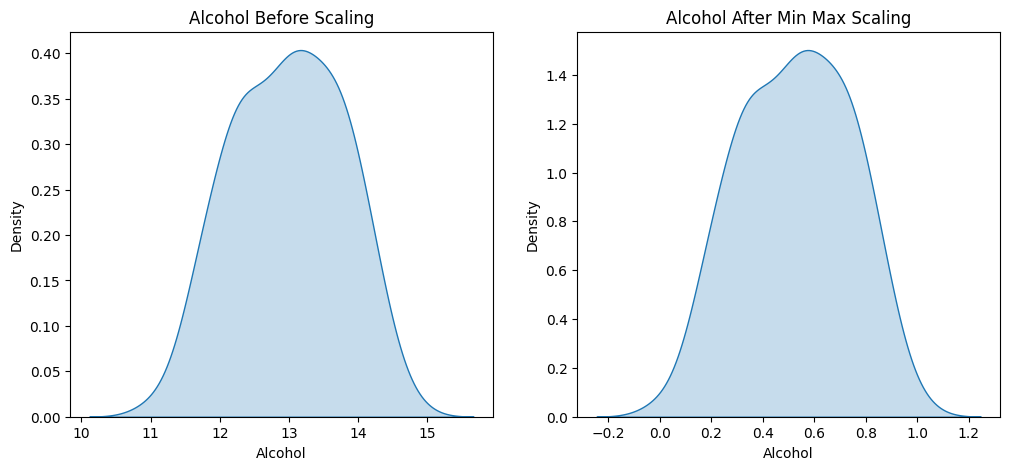

In [14]:
# alcohol distribution comparison

fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(12, 5)
)

ax1.set_title('Alcohol Before Scaling')

sns.kdeplot(
    data=X_train,
    x='Alcohol',
    ax=ax1,
    fill=True
)

ax2.set_title('Alcohol After Min Max Scaling')

sns.kdeplot(
    data=X_train_scaled,
    x='Alcohol',
    ax=ax2,
    fill=True
)

plt.show()

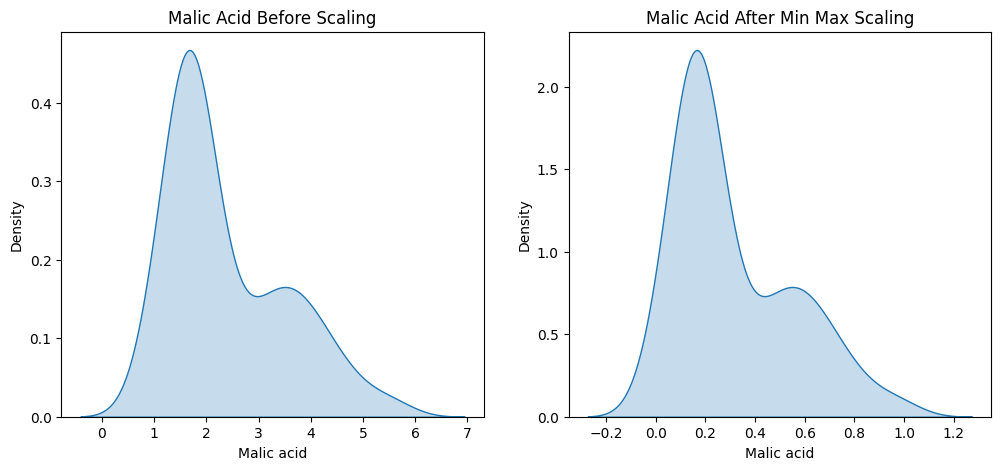

In [15]:
# malic acid distribution comparison

fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(12, 5)
)

ax1.set_title('Malic Acid Before Scaling')

sns.kdeplot(
    data=X_train,
    x='Malic acid',
    ax=ax1,
    fill=True
)

ax2.set_title('Malic Acid After Min Max Scaling')

sns.kdeplot(
    data=X_train_scaled,
    x='Malic acid',
    ax=ax2,
    fill=True
)

plt.show()

In [16]:
# checking scaling range

print(X_train_scaled.min())
print()

print(X_train_scaled.max())

Alcohol       0.0
Malic acid    0.0
dtype: float64

Alcohol       1.0
Malic acid    1.0
dtype: float64
